In [1]:
!pip install sentence-transformers

  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 596.4/596.4 kB 3.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/721.1 kB ? eta -:--:--
   ---------------------------------------- 721.1/721.1 kB 4.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.4 MB 4.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/12.4 MB 3.8 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.4 MB 4.1 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/12.4 MB 4.0 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.4 MB 4.1 MB/s eta 0:00:02
   ---------------- ----------------------- 5.2/12.4 MB 4.2 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.4 MB 4.4 MB/s eta 0:00:02
   ----------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sentence_transformers import SentenceTransformer
model_light = SentenceTransformer("cointegrated/rubert-tiny2")
model_heavy = SentenceTransformer('intfloat/multilingual-e5-large')

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 2936.44it/s]
[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 3560.95it/s]


In [8]:
import json
import numpy as np
from sentence_transformers import SentenceTransformer

with open("code_corpus.json", encoding="utf-8") as f:
    corpus = json.load(f)
corpus_100 = corpus[:100]
code_texts = [item['code'] for item in corpus_100]

embeddings_light = model_light.encode(
    code_texts,
    batch_size=16,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)
embeddings_light = embeddings_light.astype("float32")

code_texts_for_e5 = ["passage: " + code for code in code_texts]

embeddings_heavy = model_heavy.encode(
    code_texts_for_e5,
    batch_size=16,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)

embeddings_heavy = embeddings_heavy.astype("float32")
np.save("code_embeddings_light_rubert.npy", embeddings_light)
np.save("code_embeddings_heavy_e5.npy", embeddings_heavy)


# 8. Сохраняем метаданные
metadata = []

for i, item in enumerate(corpus_100):
    metadata.append({
        "index": i,
        "id": item["id"],
        "function_name": item["function_name"],
        "category": item["category"],
        "description": item["description"],
        "code": item["code"]
    })


with open("code_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)


# 9. Проверка результата
print("Готово")

print("Light model embeddings shape:", embeddings_light.shape)
print("Heavy model embeddings shape:", embeddings_heavy.shape)

print("Сохранено:")
print("code_embeddings_light_rubert.npy")
print("code_embeddings_heavy_e5.npy")
print("code_metadata.json")

with open("eval_questions.json", encoding="utf-8") as f:
    questions = json.load(f)
test_questions = questions[:15]

embeddings_light = np.load("code_embeddings_light_rubert.npy")
embeddings_heavy = np.load("code_embeddings_heavy_e5.npy")
def cosine_similarity_numpy(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def search_top_3_numpy(query_embedding, corpus_embeddings, metadata):
    scores = []

    for code_embedding in corpus_embeddings:
        score = cosine_similarity_numpy(query_embedding, code_embedding)
        scores.append(score)

    scores = np.array(scores)

    top_indexes = np.argsort(scores)[-3:][::-1]

    results = []

    for idx in top_indexes:
        results.append({
            "score": float(scores[idx]),
            "id": metadata[idx]["id"],
            "function_name": metadata[idx]["function_name"],
            "category": metadata[idx]["category"],
            "description": metadata[idx]["description"],
            "code": metadata[idx]["code"]
        })

    return results
def evaluate_model(model, corpus_embeddings, model_name, use_e5_prefix=False):
    results = []
    hits_at_3 = 0

    print("=" * 80)
    print(f"Модель: {model_name}")
    print("=" * 80)

    for question in test_questions:
        question_id = question["question_id"]
        query = question["query"]
        correct_chunk_id = question["correct_chunk_id"]

        if use_e5_prefix:
            query_for_model = "query: " + query
        else:
            query_for_model = query

        query_embedding = model.encode(
            query_for_model,
            normalize_embeddings=True,
            convert_to_numpy=True
        ).astype("float32")

        top_3 = search_top_3_numpy(
            query_embedding=query_embedding,
            corpus_embeddings=corpus_embeddings,
            metadata=metadata
        )

        top_3_ids = [item["id"] for item in top_3]

        hit_at_3 = correct_chunk_id in top_3_ids

        if hit_at_3:
            hits_at_3 += 1

        result = {
            "question_id": question_id,
            "query": query,
            "correct_chunk_id": correct_chunk_id,
            "top_3": top_3,
            "hit_at_3": hit_at_3
        }

        results.append(result)

        print()
        print(f"Вопрос: {question_id}")
        print(f"Запрос: {query}")
        print(f"Правильный ответ: {correct_chunk_id}")
        print(f"Top-3 найденные фрагменты:")

        for rank, item in enumerate(top_3, start=1):
            print(
                f"{rank}. {item['id']} | "
                f"{item['function_name']} | "
                f"score={item['score']:.4f}"
            )

        print(f"Попал правильный ответ в top-3: {hit_at_3}")

    accuracy_at_3 = hits_at_3 / len(test_questions)

    print()
    print("=" * 80)
    print(f"Hit@3: {hits_at_3}/{len(test_questions)}")
    print(f"Accuracy@3: {accuracy_at_3:.3f}")
    print("=" * 80)

    return results

results_light = evaluate_model(
    model=model_light,
    corpus_embeddings=embeddings_light,
    model_name="rubert-tiny2",
    use_e5_prefix=False
)

results_heavy = evaluate_model(
    model=model_heavy,
    corpus_embeddings=embeddings_heavy,
    model_name="multilingual-e5-large",
    use_e5_prefix=True
)

with open("results_light_top3.json", "w", encoding="utf-8") as f:
    json.dump(results_light, f, ensure_ascii=False, indent=2)

with open("results_heavy_top3.json", "w", encoding="utf-8") as f:
    json.dump(results_heavy, f, ensure_ascii=False, indent=2)


print("Результаты сохранены.")

Batches: 100%|██████████| 7/7 [00:22<00:00,  3.17s/it]


Готово
Light model embeddings shape: (100, 312)
Heavy model embeddings shape: (100, 1024)
Сохранено:
code_embeddings_light_rubert.npy
code_embeddings_heavy_e5.npy
code_metadata.json
Модель: rubert-tiny2

Вопрос: q_01
Запрос: как проверить, истёк ли токен?
Правильный ответ: func_001
Top-3 найденные фрагменты:
1. func_072 | validate_snils | score=0.5832
2. func_001 | verify_jwt_token | score=0.5725
3. func_007 | refresh_jwt_token | score=0.5500
Попал правильный ответ в top-3: True

Вопрос: q_02
Запрос: where is password hashing implemented
Правильный ответ: func_002
Top-3 найденные фрагменты:
1. func_002 | hash_password | score=0.7023
2. func_003 | check_password | score=0.6618
3. func_036 | rollback_transaction | score=0.6511
Попал правильный ответ в top-3: True

Вопрос: q_03
Запрос: проверка двухфакторной аутентификации по коду
Правильный ответ: func_014
Top-3 найденные фрагменты:
1. func_015 | generate_2fa_secret | score=0.7203
2. func_014 | validate_2fa_code | score=0.7166
3. func_00

                           Модель  Precision@3
0       cointegrated/rubert-tiny2     0.533333
1  intfloat/multilingual-e5-large     0.733333
Лучшая модель: intfloat/multilingual-e5-large


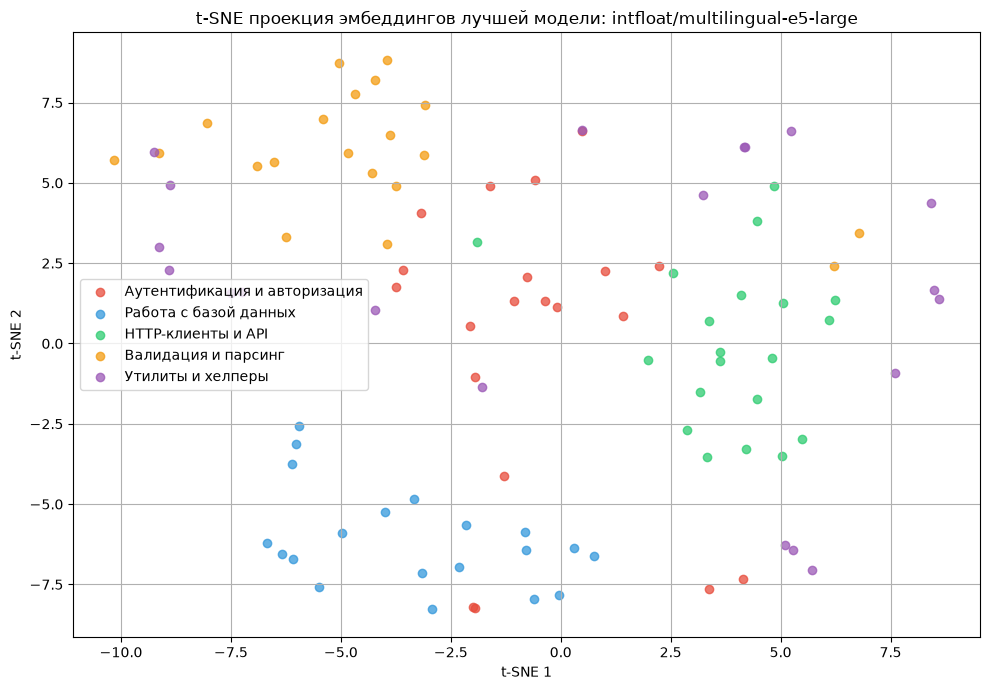

In [14]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


# =========================
# 1. Загружаем результаты
# =========================

with open("results_light_top3.json", encoding="utf-8") as f:
    results_light = json.load(f)

with open("results_heavy_top3.json", encoding="utf-8") as f:
    results_heavy = json.load(f)


# =========================
# 2. Считаем Precision@3
# =========================

def precision_at_3(results):
    correct_count = 0

    for item in results:
        if item["hit_at_3"] == True:
            correct_count += 1

    return correct_count / len(results)


precision_light = precision_at_3(results_light)
precision_heavy = precision_at_3(results_heavy)


summary_table = pd.DataFrame([
    {
        "Модель": "cointegrated/rubert-tiny2",
        "Precision@3": precision_light
    },
    {
        "Модель": "intfloat/multilingual-e5-large",
        "Precision@3": precision_heavy
    }
])

print(summary_table)

summary_table.to_csv(
    "precision_at_3_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# =========================
# 3. Выбираем лучшую модель
# =========================

if precision_light >= precision_heavy:
    best_model_name = "cointegrated/rubert-tiny2"
    best_embeddings_file = "code_embeddings_light_rubert.npy"
else:
    best_model_name = "intfloat/multilingual-e5-large"
    best_embeddings_file = "code_embeddings_heavy_e5.npy"

print("Лучшая модель:", best_model_name)


# =========================
# 4. Загружаем эмбеддинги и метаданные
# =========================

embeddings = np.load(best_embeddings_file)

with open("code_metadata.json", encoding="utf-8") as f:
    metadata = json.load(f)

with open("categories.json", encoding="utf-8") as f:
    categories_data = json.load(f)["categories"]


category_info = {
    item["key"]: {
        "label": item["label"],
        "color": item["color"]
    }
    for item in categories_data
}

point_categories = [item["category"] for item in metadata]


# =========================
# 5. t-SNE
# =========================

perplexity_value = min(30, len(embeddings) - 1)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity_value,
    init="random",
    learning_rate="auto"
)

coords = tsne.fit_transform(embeddings)


# =========================
# 6. График
# =========================

plt.figure(figsize=(10, 7))

for category_key, info in category_info.items():
    x_values = []
    y_values = []

    for i, category in enumerate(point_categories):
        if category == category_key:
            x_values.append(coords[i, 0])
            y_values.append(coords[i, 1])

    plt.scatter(
        x_values,
        y_values,
        label=info["label"],
        color=info["color"],
        alpha=0.75
    )


plt.title(f"t-SNE проекция эмбеддингов лучшей модели: {best_model_name}")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("tsne_best_model.png", dpi=300)
plt.show()